In [ ]:
!pip install -U "transformers" "torch" "accelerate"


In [ ]:
from transformers import pipeline


In [ ]:
emotion_classifier = pipeline(
    task="text-classification",
    model="joeddav/distilbert-base-uncased-go-emotions-student",
    return_all_scores=True
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
def get_emotions(text, top_k=3):

    result = emotion_classifier(text)

    # Handle both output formats safely
    if isinstance(result[0], list):
        scores = result[0]
    else:
        scores = result

    scores = sorted(scores, key=lambda x: x["score"], reverse=True)
    return scores[:top_k]


In [ ]:
text = "I feel very sad and lonely but still hopeful"
emotions = get_emotions(text)

for e in emotions:
    print(f"{e['label']} : {e['score']:.3f}")


sadness : 0.275


In [ ]:
def test(text):
    print("Input:", text)
    emos = get_emotions(text)
    for e in emos:
        print(f"{e['label']} : {e['score']:.3f}")
    print("-" * 40)

test("I feel anxious but hopeful")
test("I am extremely happy today!")
test("I am frustrated and angry")


Input: I feel anxious but hopeful
nervousness : 0.402
----------------------------------------
Input: I am extremely happy today!
joy : 0.205
----------------------------------------
Input: I am frustrated and angry
anger : 0.469
----------------------------------------


In [ ]:
while True:
    user_message = input("Enter a message (or 'quit' to stop): ")

    if user_message.lower() == "quit":
        break

    emotions = get_emotions(user_message)

    print("\nTop emotions:")
    for e in emotions:
        print(f"{e['label']} : {e['score']:.3f}")
    print("\n" + "-"*40 + "\n")


Enter a message (or 'quit' to stop): i am felling happy

Top emotions:
joy : 0.252

----------------------------------------

Enter a message (or 'quit' to stop): quit


In [ ]:
user_chat = [
    "I am feeling very stressed today",
    "I am so happy with my exam results!",
    "I feel lonely sometimes",
    "I am excited for tomorrow"
]


In [ ]:
import pandas as pd

data = []

for msg in user_chat:
    for e in get_emotions(msg):
        data.append({
            "message": msg,
            "emotion": e["label"],
            "score": e["score"]
        })

df = pd.DataFrame(data)
df


,message,emotion,score
0,I am feeling very stressed today,nervousness,0.484028
1,I am so happy with my exam results!,excitement,0.222196
2,I feel lonely sometimes,sadness,0.494364
3,I am excited for tomorrow,excitement,0.325426


In [ ]:
negative_emotions = df[df["emotion"].isin(["sadness", "anger", "fear", "grief"])]
negative_emotions


,message,emotion,score
2,I feel lonely sometimes,sadness,0.494364


In [ ]:
df.groupby("emotion")["score"].mean().sort_values(ascending=False)


,score
emotion,
sadness,0.494364
nervousness,0.484028
excitement,0.273811


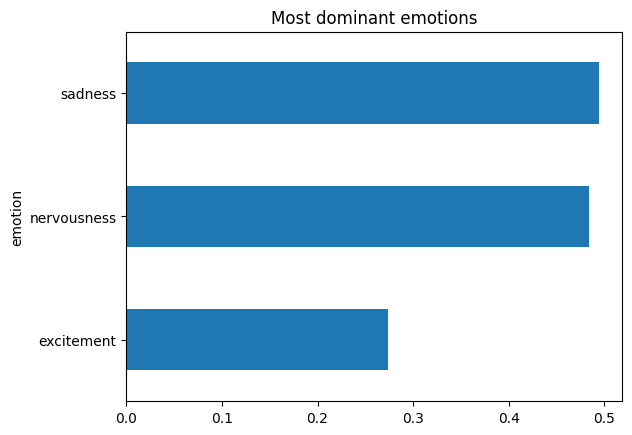

In [ ]:
import matplotlib.pyplot as plt

avg_scores = df.groupby("emotion")["score"].mean().sort_values()

avg_scores.tail(10).plot(kind="barh")  # top 10 emotions
plt.title("Most dominant emotions")
plt.show()


In [ ]:
def analyze_message(text):
    emotions = get_emotions(text)
    return {e["label"]: round(e["score"], 3) for e in emotions}


In [ ]:
analyze_message("I am very tired but hopeful for tomorrow")


{'desire': 0.171}

In [ ]:
emotion_classifier.model.save_pretrained("emotion_detection_model")
emotion_classifier.tokenizer.save_pretrained("emotion_detection_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('emotion_detection_model/tokenizer_config.json',
 'emotion_detection_model/tokenizer.json')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Save to Google Drive (Pipeline Version)
save_path = "/content/drive/MyDrive/emotion_model"

emotion_classifier.model.save_pretrained(save_path)
emotion_classifier.tokenizer.save_pretrained(save_path)

print("Model saved permanently in Google Drive ✅")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved permanently in Google Drive ✅


In [ ]:
!zip -r emotion_model.zip /content/drive/MyDrive/emotion_model

updating: content/drive/MyDrive/emotion_model/ (stored 0%)
updating: content/drive/MyDrive/emotion_model/config.json (deflated 60%)
updating: content/drive/MyDrive/emotion_model/model.safetensors (deflated 8%)
updating: content/drive/MyDrive/emotion_model/tokenizer_config.json (deflated 45%)
updating: content/drive/MyDrive/emotion_model/tokenizer.json (deflated 71%)


In [ ]:
from google.colab import files
files.download("emotion_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>